# Handwriting Data Merging UCI and PaHaW Datasets

This notebook explores the pipeline to merge the two datasets



## UCI dataset
The UCI dataset has
0: Static Spiral Test ( Draw on the given spiral pattern)
1: Dynamic Spiral Test ( Spiral pattern will blink in a certain time, 
so subjects need to continue on their draw)
2: Circular Motion Test (Subjectd draw circles around the red point)

I had to only make sure we were using those with testID = 0 because only the 
static spiral test is comparable to our PaHaw dataset.

One of the data records had testID = 2, so I deleted that record


In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

print("✅ Libraries imported successfully")

✅ Libraries imported successfully


## 1. Configure Data Paths

In [15]:
import os
from pathlib import Path

# Current notebook location
CURRENT_DIR = Path.cwd()
print("Current directory:", CURRENT_DIR)

# Go up one level to the handwriting folder
HANDWRITING_DIR = CURRENT_DIR.parent
print("Handwriting directory:", HANDWRITING_DIR)

# Dataset folders
UCI_DIR = HANDWRITING_DIR / "UCI Dataset" / "new_dataset" / "parkinson"
PAHAW_DIR = HANDWRITING_DIR / "Pahaw Dataset/PaHaW_public"

# Processed folder (where this notebook lives)
PROCESSED_DIR = CURRENT_DIR

# Optional outputs folder
OUTPUT_DIR = CURRENT_DIR.parent.parent / "outputs" / "handwriting_eda"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("\nPaths:")
print("UCI_DIR:", UCI_DIR)
print("PAHAW_DIR:", PAHAW_DIR)
print("PROCESSED_DIR:", PROCESSED_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)



Current directory: c:\Users\megha\OneDrive\Attachments\Desktop\Homework\Projects in BME AI\Project_biomed_AI\Enhancing-Multimodal-Parkinsons-Disease-Classification-and-Explainability\replica\data\handwriting\processed
Handwriting directory: c:\Users\megha\OneDrive\Attachments\Desktop\Homework\Projects in BME AI\Project_biomed_AI\Enhancing-Multimodal-Parkinsons-Disease-Classification-and-Explainability\replica\data\handwriting

Paths:
UCI_DIR: c:\Users\megha\OneDrive\Attachments\Desktop\Homework\Projects in BME AI\Project_biomed_AI\Enhancing-Multimodal-Parkinsons-Disease-Classification-and-Explainability\replica\data\handwriting\UCI Dataset\new_dataset\parkinson
PAHAW_DIR: c:\Users\megha\OneDrive\Attachments\Desktop\Homework\Projects in BME AI\Project_biomed_AI\Enhancing-Multimodal-Parkinsons-Disease-Classification-and-Explainability\replica\data\handwriting\Pahaw Dataset\PaHaW_public
PROCESSED_DIR: c:\Users\megha\OneDrive\Attachments\Desktop\Homework\Projects in BME AI\Project_biomed_A

In [16]:
# Count number of files
print("Number of UCI .txt files:", len(list(UCI_DIR.rglob("*.txt"))))
print("Number of PaHaW .svc files:", len(list(PAHAW_DIR.rglob("*.svc"))))

Number of UCI .txt files: 36
Number of PaHaW .svc files: 88


## 2. Load one file from each dataset, inspect them, and standardize the format

In [17]:
uci_example = next(UCI_DIR.rglob("*.txt"), None)
pahaw_example = next(PAHAW_DIR.rglob("*.svc"), None)

print("UCI example:", uci_example)
print("PaHaW example:", pahaw_example)

UCI example: c:\Users\megha\OneDrive\Attachments\Desktop\Homework\Projects in BME AI\Project_biomed_AI\Enhancing-Multimodal-Parkinsons-Disease-Classification-and-Explainability\replica\data\handwriting\UCI Dataset\new_dataset\parkinson\H_P000-0001.txt
PaHaW example: c:\Users\megha\OneDrive\Attachments\Desktop\Homework\Projects in BME AI\Project_biomed_AI\Enhancing-Multimodal-Parkinsons-Disease-Classification-and-Explainability\replica\data\handwriting\Pahaw Dataset\PaHaW_public\00001\00001__1_1.svc


In [21]:
# Simple preview loaders
import pandas as pd

def load_uci_preview(file_path):
    df = pd.read_csv(file_path, sep=";", header=None)

    df.columns = [
        "X",
        "Y",
        "Z",
        "Pressure",
        "GripAngle",
        "Timestamp",
        "TestID"
    ]

    return df


def load_pahaw_preview(file_path):
    df = pd.read_csv(
        file_path,
        sep=r"\s+",
        skiprows=1,   # first line is number of samples
        header=None,
        engine="python"
    )
    df.columns = ["y", "x", "timestamp", "button", "azimuth", "altitude", "pressure"]
    return df

In [22]:

uci_df = load_uci_preview(uci_example)
pahaw_df = load_pahaw_preview(pahaw_example)

print("UCI preview:")
display(uci_df.head())
print("UCI shape:", uci_df.shape)

print("\nPaHaW preview:")
display(pahaw_df.head())
print("PaHaW shape:", pahaw_df.shape)

UCI preview:


,X,Y,Z,Pressure,GripAngle,Timestamp,TestID
0,201,200,0,20,880,68140147,0
1,201,200,0,86,900,68140154,0
2,201,200,0,123,900,68140161,0
3,201,200,0,146,900,68140168,0
4,201,200,0,158,900,68140175,0


UCI shape: (9544, 7)

PaHaW preview:


,y,x,timestamp,button,azimuth,altitude,pressure
0,4161,2474,625877,1,3447,633,78
1,4164,2472,625884,1,3457,624,124
2,4166,2472,625892,1,3457,624,162
3,4167,2471,625899,1,3457,624,212
4,4168,2471,625907,1,3457,624,266


PaHaW shape: (1772, 7)


In [23]:
# Sanity check: plot the spirals to confirm they look correct

import matplotlib.pyplot as plt

def plot_uci_spiral(df, title="UCI Spiral"):

    df = df[df["TestID"] == 0]

    plt.figure(figsize=(5,5))
    plt.plot(df["X"], df["Y"])
    plt.gca().invert_yaxis()
    plt.title(title)
    plt.axis("equal")
    plt.show()


def plot_pahaw_spiral(df, title="PaHaW Spiral"):

    plt.figure(figsize=(5,5))
    plt.plot(df["x"], df["y"])
    plt.gca().invert_yaxis()
    plt.title(title)
    plt.axis("equal")
    plt.show()

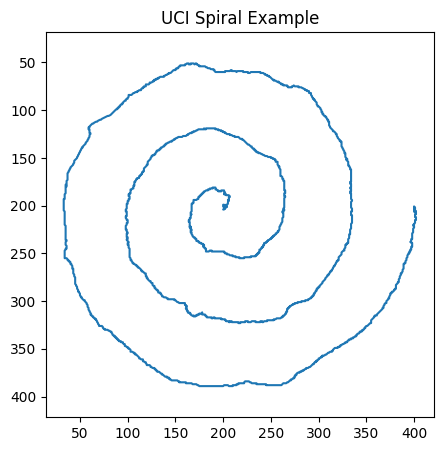

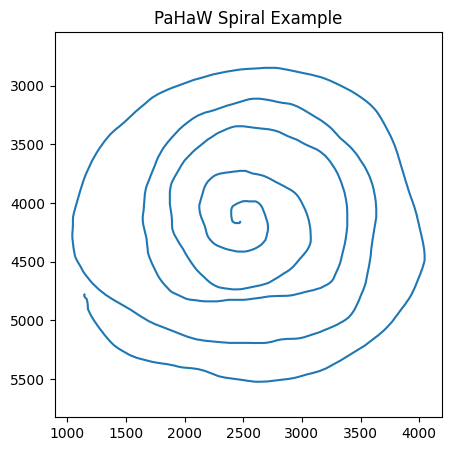

In [24]:
plot_uci_spiral(uci_df, "UCI Spiral Example")
plot_pahaw_spiral(pahaw_df, "PaHaW Spiral Example")

In [27]:
def standardize_uci(df, file_name):

    df = df.copy()

    df = df[df["TestID"] == 0]

    df = df.rename(columns={
        "X":"x",
        "Y":"y",
        "Timestamp":"timestamp",
        "Pressure":"pressure"
    })

    df = df[["x","y","timestamp","pressure"]]

    df["dataset"] = "UCI"
    df["drawing_id"] = file_name
    df["subject_id"] = file_name

    return df

def standardize_pahaw(df, file_path):

    df = df.copy()

    df = df.rename(columns={
        "x":"x",
        "y":"y",
        "timestamp":"timestamp",
        "pressure":"pressure"
    })

    df = df[["x","y","timestamp","pressure"]]

    subject_id = file_path.parent.name
    drawing_id = f"{subject_id}_{file_path.stem}"

    df["dataset"] = "PaHaW"
    df["subject_id"] = subject_id
    df["drawing_id"] = drawing_id

    return df

In [28]:
# Normalize each drawing
def normalize_drawing(df):

    df = df.copy()

    # normalize X
    df["x"] = (df["x"] - df["x"].min()) / (df["x"].max() - df["x"].min())

    # normalize Y
    df["y"] = (df["y"] - df["y"].min()) / (df["y"].max() - df["y"].min())

    # normalize pressure
    df["pressure"] = (df["pressure"] - df["pressure"].min()) / (
        df["pressure"].max() - df["pressure"].min()
    )

    # reset timestamp so drawing starts at 0
    df["timestamp"] = df["timestamp"] - df["timestamp"].min()

    return df

In [29]:
uci_std = standardize_uci(uci_df, uci_example.stem)
pahaw_std = standardize_pahaw(pahaw_df, pahaw_example)

uci_norm = normalize_drawing(uci_std)
pahaw_norm = normalize_drawing(pahaw_std)

display(uci_norm.head())
display(pahaw_norm.head())


,x,y,timestamp,pressure,dataset,drawing_id,subject_id
0,0.455285,0.440828,0,0.004372,UCI,H_P000-0001,H_P000-0001
1,0.455285,0.440828,7,0.076503,UCI,H_P000-0001,H_P000-0001
2,0.455285,0.440828,14,0.116940,UCI,H_P000-0001,H_P000-0001
3,0.455285,0.440828,21,0.142077,UCI,H_P000-0001,H_P000-0001
4,0.455285,0.440828,28,0.155191,UCI,H_P000-0001,H_P000-0001


,x,y,timestamp,pressure,dataset,subject_id,drawing_id
0,0.476349,0.490841,0,0.017227,PaHaW,00001,00001_00001__1_1
1,0.475683,0.491963,7,0.056848,PaHaW,00001,00001_00001__1_1
2,0.475683,0.492710,15,0.089578,PaHaW,00001,00001_00001__1_1
3,0.475350,0.493084,22,0.132644,PaHaW,00001,00001_00001__1_1
4,0.475350,0.493458,30,0.179156,PaHaW,00001,00001_00001__1_1


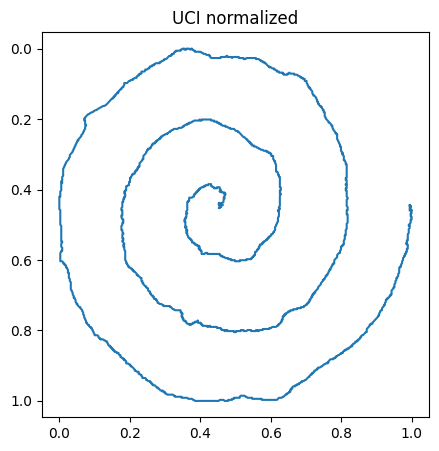

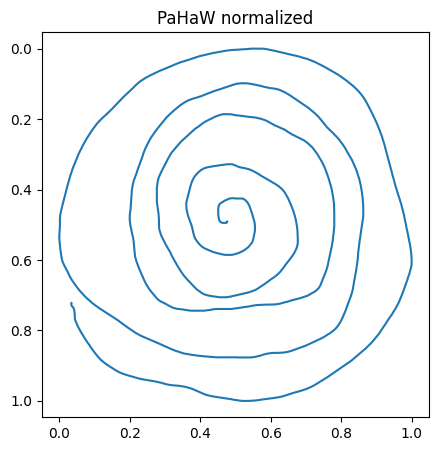

In [30]:
def plot_normalized(df, title):

    plt.figure(figsize=(5,5))
    plt.plot(df["x"], df["y"])
    plt.gca().invert_yaxis()
    plt.title(title)
    plt.axis("equal")
    plt.show()


plot_normalized(uci_norm, "UCI normalized")
plot_normalized(pahaw_norm, "PaHaW normalized")

In [31]:
import numpy as np

def resample_drawing(df, step_ms=10):

    df = df.sort_values("timestamp").copy()

    t = df["timestamp"].values
    x = df["x"].values
    y = df["y"].values
    p = df["pressure"].values

    if len(df) < 2:
        return df

    new_t = np.arange(t.min(), t.max(), step_ms)

    new_x = np.interp(new_t, t, x)
    new_y = np.interp(new_t, t, y)
    new_p = np.interp(new_t, t, p)

    new_df = pd.DataFrame({
        "timestamp": new_t,
        "x": new_x,
        "y": new_y,
        "pressure": new_p
    })

    # keep metadata
    for col in ["subject_id", "drawing_id", "dataset"]:
        new_df[col] = df.iloc[0][col]

    return new_df

In [32]:
uci_resampled = resample_drawing(uci_norm)
pahaw_resampled = resample_drawing(pahaw_norm)

print("UCI resampled shape:", uci_resampled.shape)
print("PaHaW resampled shape:", pahaw_resampled.shape)

display(uci_resampled.head())
display(pahaw_resampled.head())

UCI resampled shape: (3299, 7)
PaHaW resampled shape: (1331, 7)


,timestamp,x,y,pressure,subject_id,drawing_id,dataset
0,0,0.455285,0.440828,0.004372,H_P000-0001,H_P000-0001,UCI
1,10,0.455285,0.440828,0.093833,H_P000-0001,H_P000-0001,UCI
2,20,0.455285,0.440828,0.138486,H_P000-0001,H_P000-0001,UCI
3,30,0.455285,0.440828,0.155504,H_P000-0001,H_P000-0001,UCI
4,40,0.455285,0.438715,0.157845,H_P000-0001,H_P000-0001,UCI


,timestamp,x,y,pressure,subject_id,drawing_id,dataset
0,0,0.476349,0.490841,0.017227,00001,00001_00001__1_1,PaHaW
1,10,0.475683,0.492243,0.069121,00001,00001_00001__1_1,PaHaW
2,20,0.475445,0.492977,0.120340,00001,00001_00001__1_1,PaHaW
3,30,0.475350,0.493458,0.179156,00001,00001_00001__1_1,PaHaW
4,40,0.475017,0.493972,0.229759,00001,00001_00001__1_1,PaHaW


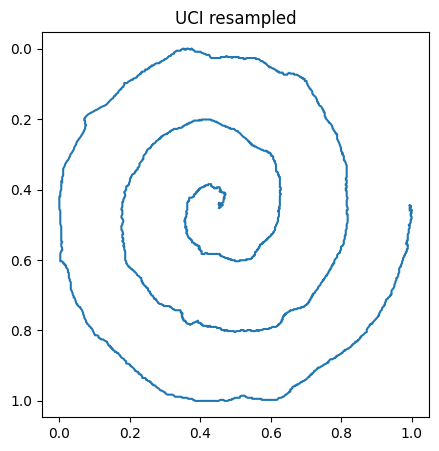

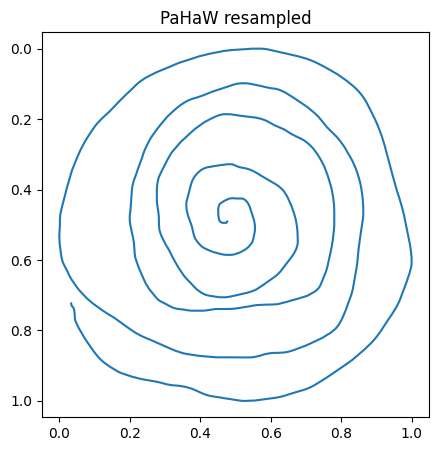

In [33]:
plot_normalized(uci_resampled, "UCI resampled")
plot_normalized(pahaw_resampled, "PaHaW resampled")

## 3. Load all the data

In [36]:
def load_all_uci(uci_dir):

    records = []

    for file_path in uci_dir.rglob("*.txt"):

        df = load_uci_preview(file_path)
        df = standardize_uci(df, file_path.stem)

        df = normalize_drawing(df)
        df = resample_drawing(df)

        records.append(df)

    return pd.concat(records, ignore_index=True)

def load_all_pahaw(pahaw_dir):

    records = []

    for file_path in pahaw_dir.rglob("*.svc"):

        df = load_pahaw_preview(file_path)
        df = standardize_pahaw(df, file_path)

        df = normalize_drawing(df)
        df = resample_drawing(df)

        records.append(df)

    return pd.concat(records, ignore_index=True)

In [38]:
uci_all = load_all_uci(UCI_DIR)
pahaw_all = load_all_pahaw(PAHAW_DIR)

print("UCI dataset shape:", uci_all.shape)
print("PaHaW dataset shape:", pahaw_all.shape)

display(uci_all.head())
display(pahaw_all.head())

UCI dataset shape: (65047, 7)
PaHaW dataset shape: (196036, 7)


,timestamp,x,y,pressure,subject_id,drawing_id,dataset
0,0,0.455285,0.440828,0.004372,H_P000-0001,H_P000-0001,UCI
1,10,0.455285,0.440828,0.093833,H_P000-0001,H_P000-0001,UCI
2,20,0.455285,0.440828,0.138486,H_P000-0001,H_P000-0001,UCI
3,30,0.455285,0.440828,0.155504,H_P000-0001,H_P000-0001,UCI
4,40,0.455285,0.438715,0.157845,H_P000-0001,H_P000-0001,UCI


,timestamp,x,y,pressure,subject_id,drawing_id,dataset
0,0,0.476349,0.490841,0.017227,00001,00001_00001__1_1,PaHaW
1,10,0.475683,0.492243,0.069121,00001,00001_00001__1_1,PaHaW
2,20,0.475445,0.492977,0.120340,00001,00001_00001__1_1,PaHaW
3,30,0.475350,0.493458,0.179156,00001,00001_00001__1_1,PaHaW
4,40,0.475017,0.493972,0.229759,00001,00001_00001__1_1,PaHaW


In [39]:
merged = pd.concat([uci_all, pahaw_all], ignore_index=True)

print("Merged dataset shape:", merged.shape)

print(merged["dataset"].value_counts())

Merged dataset shape: (261083, 7)
dataset
PaHaW    196036
UCI       65047
Name: count, dtype: int64


In [40]:
merged_path = PROCESSED_DIR / "merged_handwriting_timeseries.csv"

merged.to_csv(merged_path, index=False)

print("Saved dataset to:", merged_path)

Saved dataset to: c:\Users\megha\OneDrive\Attachments\Desktop\Homework\Projects in BME AI\Project_biomed_AI\Enhancing-Multimodal-Parkinsons-Disease-Classification-and-Explainability\replica\data\handwriting\processed\merged_handwriting_timeseries.csv


In [42]:
merged = merged[
    ["subject_id", "drawing_id", "dataset", "timestamp", "x", "y", "pressure"]
]
merged_path = PROCESSED_DIR / "merged_handwriting_timeseries.csv"
merged.to_csv(merged_path, index=False)

In [43]:
merged.head()

,subject_id,drawing_id,dataset,timestamp,x,y,pressure
0,H_P000-0001,H_P000-0001,UCI,0,0.455285,0.440828,0.004372
1,H_P000-0001,H_P000-0001,UCI,10,0.455285,0.440828,0.093833
2,H_P000-0001,H_P000-0001,UCI,20,0.455285,0.440828,0.138486
3,H_P000-0001,H_P000-0001,UCI,30,0.455285,0.440828,0.155504
4,H_P000-0001,H_P000-0001,UCI,40,0.455285,0.438715,0.157845


## 4. EDA Analysis

In [46]:
print("Total rows:", len(merged))
print("Columns:", merged.columns)

print("\nDatasets:")
print(merged["dataset"].value_counts())

print("\nNumber of drawings:")
print(merged["drawing_id"].nunique())

print("\nDrawings per dataset:")
print(merged.groupby("dataset")["drawing_id"].nunique())

Total rows: 261083
Columns: Index(['subject_id', 'drawing_id', 'dataset', 'timestamp', 'x', 'y',
       'pressure'],
      dtype='object')

Datasets:
dataset
PaHaW    196036
UCI       65047
Name: count, dtype: int64

Number of drawings:
124

Drawings per dataset:
dataset
PaHaW    88
UCI      36
Name: drawing_id, dtype: int64


In [47]:
print("Dataset shape:", merged.shape)

print("\nColumns:")
print(merged.columns)

print("\nDatasets:")
print(merged["dataset"].value_counts())

print("\nUnique drawings:")
print(merged["drawing_id"].nunique())

print("\nUnique subjects:")
print(merged["subject_id"].nunique())

Dataset shape: (261083, 7)

Columns:
Index(['subject_id', 'drawing_id', 'dataset', 'timestamp', 'x', 'y',
       'pressure'],
      dtype='object')

Datasets:
dataset
PaHaW    196036
UCI       65047
Name: count, dtype: int64

Unique drawings:
124

Unique subjects:
111


In [48]:
samples_per_drawing = merged.groupby("drawing_id").size()

print(samples_per_drawing.describe())

count      124.000000
mean      2105.508065
std       1682.226233
min        370.000000
25%       1245.250000
50%       1667.500000
75%       2360.500000
max      12310.000000
dtype: float64


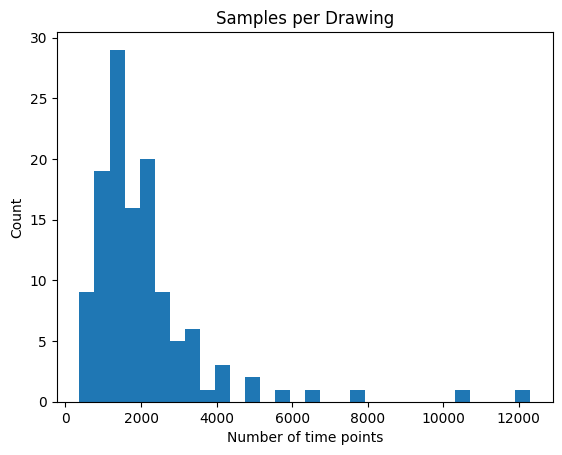

In [49]:
import matplotlib.pyplot as plt

plt.hist(samples_per_drawing, bins=30)
plt.title("Samples per Drawing")
plt.xlabel("Number of time points")
plt.ylabel("Count")
plt.show()

In [50]:
duration = merged.groupby("drawing_id")["timestamp"].max()

print(duration.describe())

count       124.000000
mean      21045.080645
std       16822.262326
min        3690.000000
25%       12442.500000
50%       16665.000000
75%       23595.000000
max      123090.000000
Name: timestamp, dtype: float64


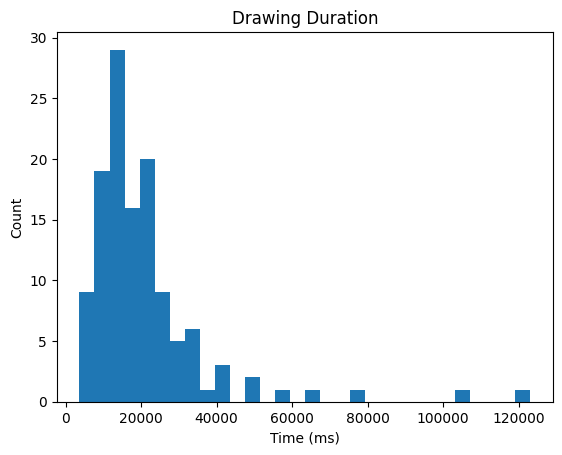

In [51]:
plt.hist(duration, bins=30)
plt.title("Drawing Duration")
plt.xlabel("Time (ms)")
plt.ylabel("Count")
plt.show()

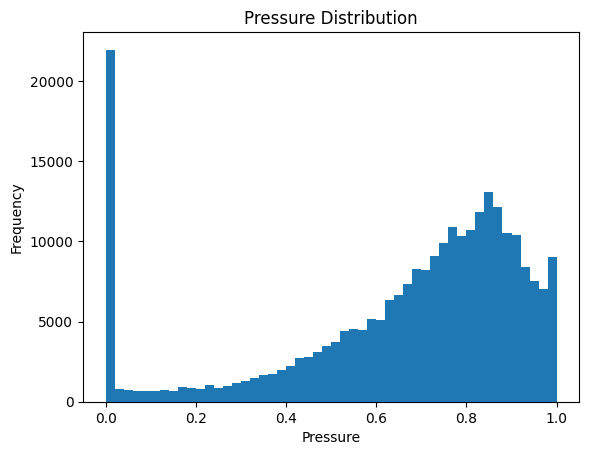

In [52]:
plt.hist(merged["pressure"], bins=50)
plt.title("Pressure Distribution")
plt.xlabel("Pressure")
plt.ylabel("Frequency")
plt.show()

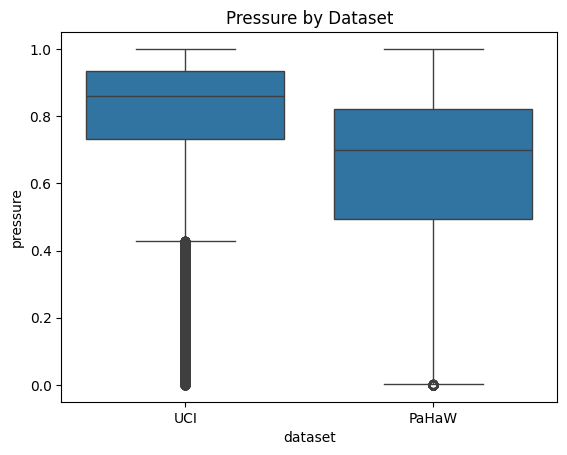

In [53]:
import seaborn as sns

sns.boxplot(data=merged, x="dataset", y="pressure")
plt.title("Pressure by Dataset")
plt.show()

In [54]:
import numpy as np

merged = merged.sort_values(["drawing_id","timestamp"])

merged["dx"] = merged.groupby("drawing_id")["x"].diff()
merged["dy"] = merged.groupby("drawing_id")["y"].diff()
merged["dt"] = merged.groupby("drawing_id")["timestamp"].diff()

merged["velocity"] = np.sqrt(merged["dx"]**2 + merged["dy"]**2) / merged["dt"]

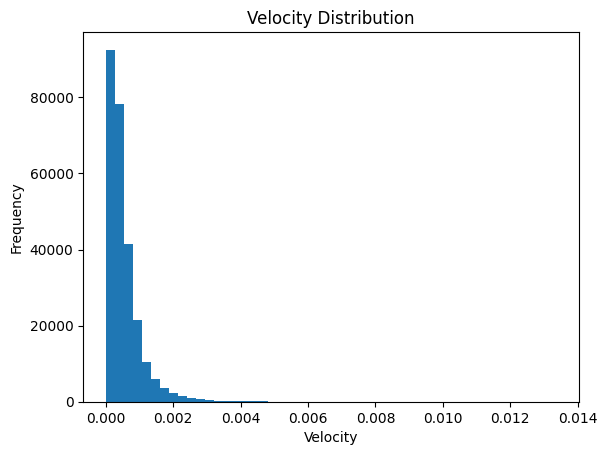

In [55]:
plt.hist(merged["velocity"].dropna(), bins=50)
plt.title("Velocity Distribution")
plt.xlabel("Velocity")
plt.ylabel("Frequency")
plt.show()

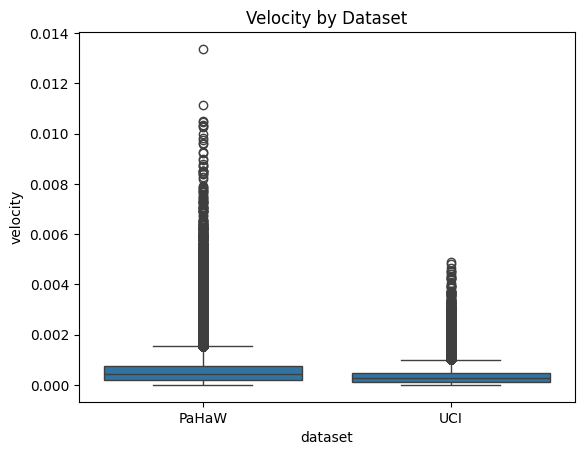

In [56]:
sns.boxplot(data=merged, x="dataset", y="velocity")
plt.title("Velocity by Dataset")
plt.show()

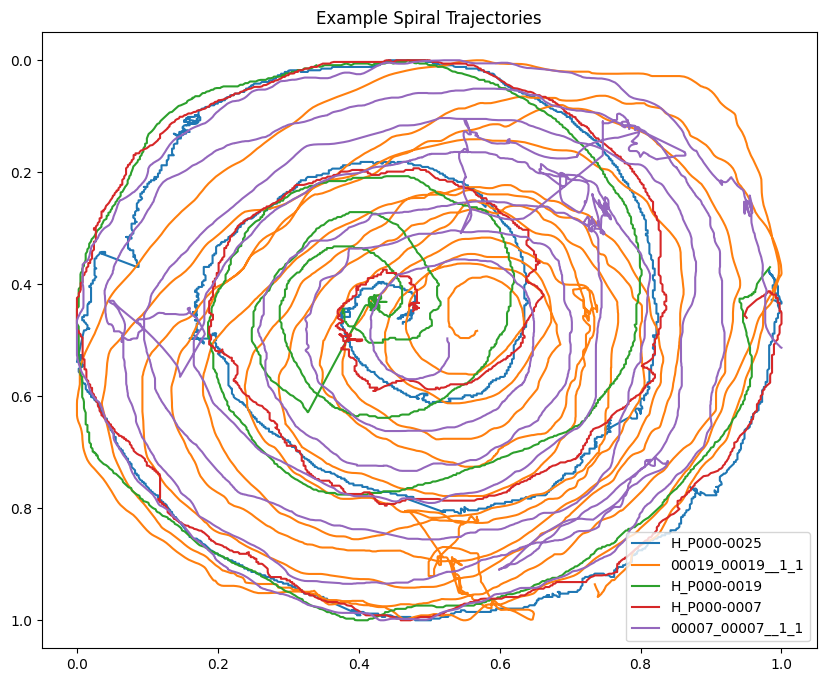

In [57]:
sample_drawings = merged["drawing_id"].sample(5).unique()

plt.figure(figsize=(10,8))

for d in sample_drawings:
    
    df = merged[merged["drawing_id"] == d]
    
    plt.plot(df["x"], df["y"], label=d)

plt.gca().invert_yaxis()
plt.title("Example Spiral Trajectories")
plt.legend()
plt.show()

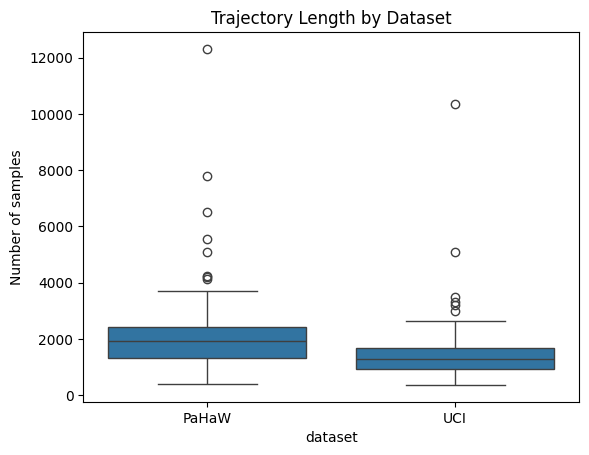

In [58]:
samples_dataset = merged.groupby(["dataset","drawing_id"]).size()

sns.boxplot(x=samples_dataset.index.get_level_values(0),
            y=samples_dataset.values)

plt.title("Trajectory Length by Dataset")
plt.ylabel("Number of samples")
plt.show()

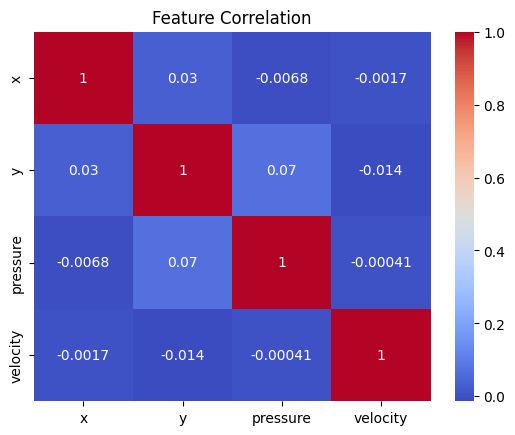

In [59]:
corr = merged[["x","y","pressure","velocity"]].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

## Interpretation
Most spiral drawings lasted between approximately 10 and 25 seconds. A small number of outliers extend beyond 60 seconds, reaching up to approximately 120 seconds. These longer recordings likely reflect differences in experimental protocols or drawing speeds across datasets.

The pressure distribution shows a strong concentration near zero, representing moments when the pen is lifted or barely contacting the tablet surface. Most active drawing pressure values fall between 0.6 and 1.0 after normalization, indicating consistent stylus contact during drawing movements.

Pressure distributions differ slightly between datasets, likely due to differences in digitizing tablet hardware and pressure sensor calibration. Despite normalization, PaHaW recordings show a slightly wider pressure variability compared to UCI.

The velocity distribution is highly right-skewed, with most movements occurring at relatively low speeds and a small number of rapid movements producing higher velocity values. This pattern is typical in handwriting trajectories where fine motor adjustments occur frequently.

Visual inspection of spiral trajectories shows consistent spiral structures across subjects, with variability in smoothness and curvature. These variations may reflect differences in motor control and tremor patterns across individuals.

PaHaW recordings tend to contain more time samples than UCI recordings, suggesting longer drawing durations or higher sampling density in the PaHaW dataset.

Correlation analysis reveals minimal linear relationships between spatial coordinates, pressure, and velocity features. This suggests that these variables capture distinct aspects of handwriting dynamics and may provide complementary information for downstream modeling.
